# LightGBM Ranking on Amazon Books

End-to-end demo of `LightGBMClassifierEstimator` on the **Amazon Reviews 2023 — Books** category.

**Why LightGBM here?** A fast, CPU-only gradient-boosted tree model that handles the
categorical-rich book metadata (categories, publisher, price tier) without a PyTorch
dependency. This notebook is the fast cousin of [`ranking_xgboost_movielens1m.ipynb`](ranking_xgboost_movielens1m.ipynb)
on a different dataset and a different tabular estimator.

**Evaluation protocol**: leave-last-positive-out — for each user, the last interaction
with rating ≥ 4 is the test item; everything else (positive *and* negative ratings) is the
training set. Including low ratings as observed negatives gives LightGBM real dislike signal.

**Metrics**: HR@10 and NDCG@10 on a sampled ranking task (1 positive + 100 random negatives).

**Data**: McAuley-Lab/Amazon-Reviews-2023 Books category, streamed via HuggingFace
`datasets` and cached to `data/raw/` (shared across the four Books notebooks).

## 1. Imports

In [1]:
import logging
from pathlib import Path

import numpy as np
import pandas as pd

from skrec.dataset.interactions_dataset import InteractionsDataset
from skrec.dataset.items_dataset import ItemsDataset
from skrec.estimator.classification.lightgbm_classifier import LightGBMClassifierEstimator
from skrec.recommender.ranking.ranking_recommender import RankingRecommender
from skrec.scorer.universal import UniversalScorer

logging.basicConfig(level=logging.WARNING)

RAW_DIR = Path("data/raw")
RAW_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = Path("data/lightgbm")
DATA_DIR.mkdir(parents=True, exist_ok=True)
print("Imports OK")

Imports OK


## 2. Download + sample Amazon Books

We pull the McAuley Lab **Amazon Reviews 2023** 5-core Books rating CSV directly from
HuggingFace via `hf_hub_download` (one ~525 MB file, no `datasets` library needed). This
gives us `(user, item, rating, timestamp)` for every 5-core review. We then sample 100k
users with a deterministic seed.

The full Books metadata file (titles, categories, publisher, price) is 14 GB — impractical
for a notebook. These notebooks therefore rely on **interaction-derived features only**:
item popularity, item rating statistics, user behavioural statistics. The recommender
displays book IDs in place of titles.

The cached parquet is **shared across all four Books notebooks** — first run pays the
download cost (~1–3 min); the rest hit the cache instantly.

In [2]:
INTERACTIONS_PARQUET = RAW_DIR / "interactions.parquet"

TARGET_N_USERS = 100_000
SEED = 42

if INTERACTIONS_PARQUET.exists():
    print(f"Cache hit at {INTERACTIONS_PARQUET} — skipping download.")
else:
    try:
        from huggingface_hub import hf_hub_download
    except ImportError:
        print("Installing huggingface_hub...")
        import subprocess
        import sys

        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub"])
        from huggingface_hub import hf_hub_download

    print("Downloading 5core/rating_only/Books.csv (~525 MB)...")
    csv_path = hf_hub_download(
        repo_id="McAuley-Lab/Amazon-Reviews-2023",
        filename="benchmark/5core/rating_only/Books.csv",
        repo_type="dataset",
    )
    print(f"  -> {csv_path}")

    # The 5core rating-only CSV has columns: user_id, parent_asin, rating, timestamp.
    # The full file is ~9.5M rows; loading it all at default pandas dtypes can OOM.
    # Two-pass chunked approach instead:
    #   Pass 1 — stream user_id only, collect unique users, sample.
    #   Pass 2 — stream all 4 columns, keep only sampled users.
    CHUNK = 2_000_000
    print("Pass 1: streaming unique users...")
    unique_users: set[str] = set()
    for chunk in pd.read_csv(csv_path, chunksize=CHUNK, usecols=["user_id"], dtype={"user_id": str}):
        unique_users.update(chunk["user_id"].unique())
    print(f"  total unique users: {len(unique_users):,}")

    rng = np.random.default_rng(SEED)
    sampled_users = set(
        rng.choice(
            np.array(sorted(unique_users)),
            size=min(TARGET_N_USERS, len(unique_users)),
            replace=False,
        )
    )
    print(f"  sampled: {len(sampled_users):,}")

    print("Pass 2: streaming and filtering...")
    parts = []
    for chunk in pd.read_csv(
        csv_path,
        chunksize=CHUNK,
        dtype={"user_id": str, "parent_asin": str, "rating": "float32", "timestamp": "int64"},
    ):
        parts.append(chunk[chunk["user_id"].isin(sampled_users)])
    df = pd.concat(parts, ignore_index=True)
    df = df.rename(columns={"user_id": "USER_ID", "parent_asin": "ITEM_ID", "timestamp": "TIMESTAMP"})
    n_users = df["USER_ID"].nunique()
    n_items = df["ITEM_ID"].nunique()
    print(f"  kept: {len(df):,} interactions across {n_users:,} users, {n_items:,} items")

    df.to_parquet(INTERACTIONS_PARQUET)
    print(f"Saved -> {INTERACTIONS_PARQUET}")

interactions = pd.read_parquet(INTERACTIONS_PARQUET)
print(f"\nLoaded {len(interactions):,} interactions.")
print(f"  users: {interactions['USER_ID'].nunique():,}  items: {interactions['ITEM_ID'].nunique():,}")
interactions.head(3)

Cache hit at data/raw/interactions.parquet — skipping download.

Loaded 1,216,565 interactions.


  users: 100,000  items: 361,673


,USER_ID,ITEM_ID,rating,TIMESTAMP
0,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1446304000,5.0,1441260345000
1,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1564770672,5.0,1441260365000
2,AFKZENTNBQ7A7V7UXW5JJI6UGRYQ,1442450703,5.0,1523093714024


## 3. Item Feature Engineering (interaction-derived only)

The McAuley Books metadata file is 14 GB — too large for a notebook download. We instead
derive item features purely from interaction data:

- `item_rating_mean` — average rating across all reviewers (a quality signal)
- `item_rating_count_log` — log of review count (popularity proxy)
- `item_rating_std` — variability in ratings the item receives (controversial vs. uniformly liked)

These are computed from the **training split only** in §5 to avoid leakage of test items.

In [3]:
all_items = sorted(interactions["ITEM_ID"].unique())
items_df = pd.DataFrame({"ITEM_ID": all_items})
print(f"Catalog: {len(items_df):,} unique items")
items_df.head(3)

Catalog: 361,673 unique items


,ITEM_ID
0,0000013714
1,000100039X
2,0001061240


## 4. Train / Test Split (Leave-Last-Positive-Out)

For each user the **last positive interaction** (rating ≥ 4 by timestamp) becomes the
test item; every other interaction — positive and negative — is training data.
Users with fewer than 3 total interactions are dropped.

**OUTCOME** is binary: rating ≥ 4 → 1.0, otherwise 0.0. LightGBM trains on this label
with the engineered features as inputs.

In [4]:
df = interactions.copy()
df["OUTCOME"] = (df["rating"] >= 4).astype(float)
df = df.sort_values(["USER_ID", "TIMESTAMP"]).reset_index(drop=True)

# Drop users with < 3 interactions
counts = df.groupby("USER_ID").size()
df = df[df["USER_ID"].isin(counts[counts >= 3].index)].reset_index(drop=True)

# Per-user last positive → test
pos = df[df["OUTCOME"] == 1.0]
last_pos_idx = pos.groupby("USER_ID")["TIMESTAMP"].idxmax()
test_df = pos.loc[last_pos_idx].reset_index(drop=True)

train_df = df.drop(index=last_pos_idx).reset_index(drop=True)
test_df = test_df[test_df["USER_ID"].isin(train_df["USER_ID"].unique())].reset_index(drop=True)

print(f"Train : {len(train_df):,} interactions  (positive rate: {train_df.OUTCOME.mean():.1%})")
print(f"Test  : {len(test_df):,} interactions  (one per user)")
print(f"Users : {train_df.USER_ID.nunique():,} train  |  {test_df.USER_ID.nunique():,} test")

Train : 1,116,932 interactions  (positive rate: 83.3%)
Test  : 99,633 interactions  (one per user)
Users : 100,000 train  |  99,633 test


## 5. Compute item + user features from training data only

Both feature groups are derived from the train split, then:

- **Item features** are joined onto `items_df` (per-item static columns).
- **User features** are attached to each interaction row so the `UniversalScorer`
  can replicate them across candidate items at scoring time.

In [5]:
# --- item features ---
item_stats = (
    train_df.groupby("ITEM_ID")["rating"]
    .agg(item_rating_mean="mean", item_rating_count="count", item_rating_std="std")
    .fillna(0.0)
    .reset_index()
)
item_stats["item_rating_count_log"] = np.log1p(item_stats["item_rating_count"])
item_stats = item_stats[["ITEM_ID", "item_rating_mean", "item_rating_count_log", "item_rating_std"]]

items_df = items_df.merge(item_stats, on="ITEM_ID", how="left").fillna(
    {"item_rating_mean": 0.0, "item_rating_count_log": 0.0, "item_rating_std": 0.0}
)
# Restrict catalog to items seen in train+test
used_items = set(train_df["ITEM_ID"]).union(set(test_df["ITEM_ID"]))
items_df = items_df[items_df["ITEM_ID"].isin(used_items)].reset_index(drop=True)

# --- user features ---
user_stats = (
    train_df.groupby("USER_ID")["rating"]
    .agg(user_rating_mean="mean", user_rating_count="count", user_rating_std="std")
    .fillna(0.0)
    .reset_index()
)
user_stats["user_rating_count_log"] = np.log1p(user_stats["user_rating_count"])
user_stats = user_stats[["USER_ID", "user_rating_mean", "user_rating_count_log", "user_rating_std"]]

train_df = train_df.merge(user_stats, on="USER_ID", how="left")
print(f"Items × features: {items_df.shape}")
print(f"Users × features: {user_stats.shape}")
items_df.head(3)

Items × features: (361673, 4)
Users × features: (100000, 4)


,ITEM_ID,item_rating_mean,item_rating_count_log,item_rating_std
0,0000013714,5.00,0.693147,0.0
1,000100039X,4.25,1.609438,1.5
2,0001061240,5.00,0.693147,0.0


## 6. Save CSVs and Build Datasets

scikit-rec datasets read CSVs from disk. We materialise the prepared training set and
item catalog under `data/lightgbm-amazon-books/` (excluded from git via `.gitignore` patterns
in the parent — see existing examples).

In [6]:
train_path = str(DATA_DIR / "train_interactions.csv")
items_path = str(DATA_DIR / "items.csv")

train_to_save = train_df[
    ["USER_ID", "ITEM_ID", "OUTCOME", "user_rating_mean", "user_rating_count_log", "user_rating_std"]
]
if not Path(train_path).exists():
    train_to_save.to_csv(train_path, index=False)
if not Path(items_path).exists():
    items_df.to_csv(items_path, index=False)

interactions_ds = InteractionsDataset(data_location=train_path)
items_ds = ItemsDataset(data_location=items_path)
print(f"Training data: {len(train_to_save):,} interactions × {train_to_save.shape[1]} columns")
print(f"Item catalog: {len(items_df):,} items × {items_df.shape[1] - 1} features")

Training data: 1,116,932 interactions × 6 columns
Item catalog: 361,673 items × 3 features


## 7. Build and Train LightGBM

LightGBM trains in seconds even on ~1M interactions. We wrap it in `UniversalScorer` →
`RankingRecommender` to get the standard scikit-rec scoring + ranking surface.

In [7]:
estimator = LightGBMClassifierEstimator(
    params={
        "n_estimators": 200,
        "max_depth": -1,
        "num_leaves": 63,
        "learning_rate": 0.1,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,
    }
)

scorer = UniversalScorer(estimator)
recommender = RankingRecommender(scorer)

print("Training LightGBM...")
recommender.train(interactions_ds=interactions_ds, items_ds=items_ds)
print(f"Done. Features: {estimator.feature_names}")

Training LightGBM...


Done. Features: ['user_rating_mean', 'user_rating_count_log', 'user_rating_std', 'item_rating_mean', 'item_rating_count_log', 'item_rating_std']


## 8. Feature Importance

Tree-based models give us a free interpretability layer.

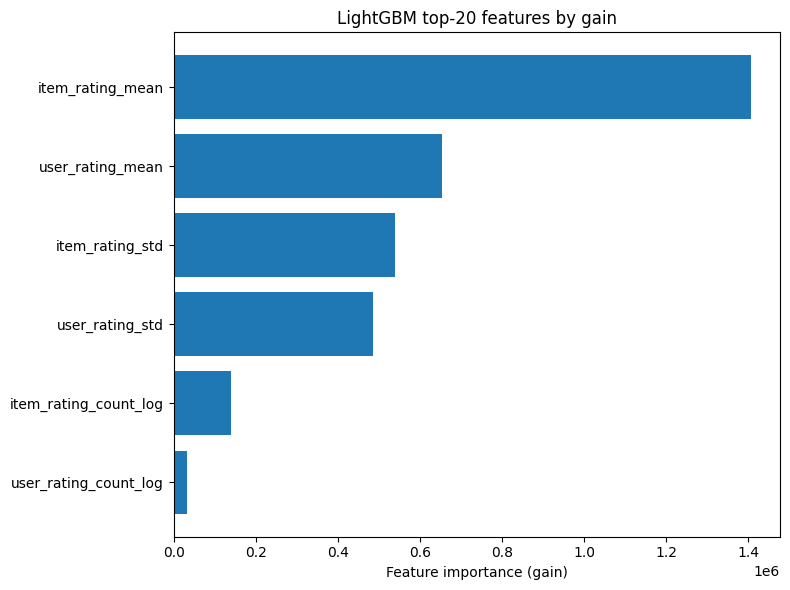

Top-5 features:
              feature         gain
item_rating_count_log 1.401785e+05
      user_rating_std 4.843984e+05
      item_rating_std 5.394413e+05
     user_rating_mean 6.523920e+05
     item_rating_mean 1.406678e+06


In [8]:
import matplotlib.pyplot as plt

booster = estimator._model.booster_
gain = booster.feature_importance(importance_type="gain")
imp_df = pd.DataFrame({"feature": estimator.feature_names, "gain": gain}).sort_values("gain", ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(imp_df["feature"], imp_df["gain"])
ax.set_xlabel("Feature importance (gain)")
ax.set_title("LightGBM top-20 features by gain")
plt.tight_layout()
plt.show()

print("Top-5 features:")
print(imp_df.tail(5).to_string(index=False))

## 9. Evaluate: HR@10 and NDCG@10 (Sampled Ranking)

The Books catalog is ~360k items, so materialising a full `(n_users × n_items)` score
matrix is infeasible. Instead, we **score only candidates per user**: for each test user
we sample 100 unseen items as negatives, build the 101-pair feature matrix once across
all eval users, and run a single batched `predict_proba`.

We also subsample to **2,000 random test users** to keep the (eval users × 101) matrix
tractable. The 2k sample gives stable HR/NDCG estimates with ~±1% standard error.

In [9]:
TOP_K, N_NEG, N_EVAL_USERS = 10, 100, 2000
rng = np.random.default_rng(42)

known_items = set(items_df["ITEM_ID"])
catalog_arr = np.array(items_df["ITEM_ID"])
eval_test = test_df[test_df["ITEM_ID"].isin(known_items)].copy()
if len(eval_test) > N_EVAL_USERS:
    eval_test = eval_test.sample(n=N_EVAL_USERS, random_state=42).reset_index(drop=True)
print(f"Evaluating {len(eval_test):,} users (sampled).")

train_seen = train_df.groupby("USER_ID")["ITEM_ID"].apply(set).to_dict()

# Build (user, candidate) pairs: 1 positive + N_NEG negatives per user
pair_user, pair_item, pair_label = [], [], []
gt = {}
for _, row in eval_test.iterrows():
    u = row["USER_ID"]
    test_item = row["ITEM_ID"]
    seen = train_seen.get(u, set())
    unseen_mask = ~np.isin(catalog_arr, list(seen))
    unseen = catalog_arr[unseen_mask]
    neg = rng.choice(unseen, size=min(N_NEG, len(unseen)), replace=False)
    pair_user.extend([u] * (1 + len(neg)))
    pair_item.append(test_item)
    pair_item.extend(neg)
    pair_label.append(1)
    pair_label.extend([0] * len(neg))
    gt[u] = test_item

pairs = pd.DataFrame({"USER_ID": pair_user, "ITEM_ID": pair_item})
pairs = pairs.merge(user_stats, on="USER_ID", how="left")
pairs = pairs.merge(items_df, on="ITEM_ID", how="left")
X = pairs[estimator.feature_names]
print(f"Scoring {len(X):,} (user, candidate) pairs...")
scores = estimator.predict_proba(X)[:, 1]

# Reshape: every (1 + N_NEG) consecutive scores belong to one user.
n_users = len(eval_test)
n_per = 1 + N_NEG
scores_2d = scores.reshape(n_users, n_per)
test_scores = scores_2d[:, 0:1]  # (n_users, 1)
ranks = (scores_2d > test_scores).sum(axis=1) + 1  # 1-indexed rank of the positive
hit = (ranks <= TOP_K).astype(int)
ndcg = np.where(ranks <= TOP_K, 1.0 / np.log2(ranks + 1), 0.0)

print(f"\n{'=' * 40}")
print(f"Sampled ranking (1 pos + {N_NEG} neg)")
print(f"HR@{TOP_K}   : {hit.mean():.4f}")
print(f"NDCG@{TOP_K} : {ndcg.mean():.4f}")
print(f"Users : {n_users:,}")
print(f"{'=' * 40}")

eval_users_list = eval_test["USER_ID"].tolist()

Evaluating 2,000 users (sampled).


Scoring 202,000 (user, candidate) pairs...

Sampled ranking (1 pos + 100 neg)
HR@10   : 0.1185
NDCG@10 : 0.1033
Users : 2,000


/Users/ssankararam/Shankar/Personal/RecSys/scikit-rec/.venv/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 10. Sample Recommendations

Top-10 books for 5 test users from their candidate pool. We rank only their 101 candidates
(1 positive + 100 negatives) since full-catalog ranking is impractical at Books scale.

In [10]:
# No title metadata available — show truncated ITEM_ID instead.
for ui in range(5):
    u = eval_users_list[ui]
    user_pair_idx = slice(ui * n_per, (ui + 1) * n_per)
    user_items = pairs.iloc[user_pair_idx]["ITEM_ID"].values
    user_scores = scores[user_pair_idx]
    order = np.argsort(-user_scores)
    top = user_items[order][:TOP_K]
    test_item = gt.get(u, "?")
    flag = "HIT" if test_item in top else "MISS"
    print(f"\nUser {u}  |  Test: {test_item}  [{flag}]")
    for r, item_id in enumerate(top, 1):
        marker = "  <-- TEST" if item_id == test_item else ""
        print(f"  {r:2}. {item_id}{marker}")


User AE4YW7GY4LKJXP3LJKKYJAHJPOKA  |  Test: B00IB5BSBG  [MISS]
   1. 0495014281
   2. B000UODXNC
   3. 1933988363
   4. 1593761163
   5. 1450411177
   6. 1595143947
   7. 1420925644
   8. B00W6FYNFK
   9. 0312272103
  10. 1790117984

User AF6LM4TAY5BOEGCP6LN4KQAMHI4Q  |  Test: 1574888862  [HIT]
   1. 1574888862  <-- TEST
   2. 1941235107
   3. 1631596152
   4. 0062002732
   5. 0877792917
   6. B01N5A4YMB
   7. 0873418069
   8. B07WH9J7J5
   9. 191008526X
  10. 1593691262

User AEEKCCQ73X6X6H65ZVPVMQHJEKYA  |  Test: 0380791714  [MISS]
   1. 1302901915
   2. 0863581617
   3. 0875167446
   4. B0013V8JA8
   5. 1400312817
   6. 0689825846
   7. 071125950X
   8. 0307346870
   9. 0425245306
  10. 0375756809

User AFTHGYDPP4RBKYNQHIK4MFG4RKLQ  |  Test: B01ATF489O  [MISS]
   1. 1933831057
   2. 1565126084
   3. 1631597639
   4. 1596434600
   5. B078XBQ84G
   6. 1596356820
   7. 1503947742
   8. 9626343087
   9. 1499801106
  10. B08GKWN7XW

User AGF6MW22N7WP4UW3OUJBEIZCQ4FQ  |  Test: 1542007267